# Scipy filters compatibility

In [1]:
import speasy as spz
from speasy.core.any_files import any_loc_open
from speasy.core.codecs import get_codec
from speasy.signal.filtering import sosfiltfilt
import numpy as np
%matplotlib widget
mms1_products = spz.inventories.tree.cda.MMS.MMS1
# Use this instead if you are not using jupyterlab yet
#%matplotlib notebook
import matplotlib.pyplot as plt
from scipy import signal
cdf_codec = get_codec("cdf")

Matplotlib is building the font cache; this may take a moment.
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
CSA webservice is not supported in WASM environment, disabling CSA provider
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
server availability check implementation can't be performed in WASM environment, assuming server is up
Non compliant ISTP file: Epoch was marked as data variable but it has 0 support variable
server availability check implementation can't be performed in WASM environment, assuming server is up
/lib/python3.13/site-packages/speasy/signal/filtering/__init__.py:1: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciP

## Loading data

Let's use the MMS1 EDP burst data from the CDAWeb to test the filtering.

In [2]:
mms1_edp_hmfe_par_epar_brst_l2 = cdf_codec.load_variable( "mms1_edp_hmfe_par_epar_brst_l2", "https://cdaweb.gsfc.nasa.gov/pub/data/mms/mms1/edp/brst/l2/hmfe/2021/07/mms1_edp_brst_l2_hmfe_20210701020013_v2.0.0.cdf")

In [3]:
sampling_frequency = 1e9/float(mms1_edp_hmfe_par_epar_brst_l2.time[1]-mms1_edp_hmfe_par_epar_brst_l2.time[0])
sampling_frequency

65535.09404285995

## Filtering with scipy.signal 

Let's design a time domain bandpass filter with scipy.signal cutting off frequencies below 100 Hz and above 10 kHz.

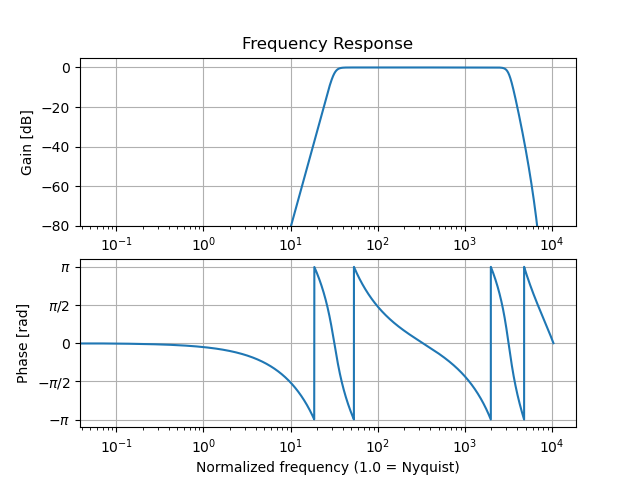

In [4]:
sos = signal.iirfilter(N=8, Wn=[100, 10000], rs=80, btype='bandpass',output='sos', fs=sampling_frequency)
w, h = signal.sosfreqz(sos, worN=150000, fs=sampling_frequency)
plt.figure()
plt.subplot(2, 1, 1)
db = 20*np.log10(np.maximum(np.abs(h), 1e-5))
plt.plot(w/np.pi, db)
plt.ylim(-75, 5)
plt.grid(True)
plt.yticks([0, -20, -40, -60, -80])
plt.semilogx()
plt.ylabel('Gain [dB]')
plt.title('Frequency Response')
plt.subplot(2, 1, 2)
plt.plot(w/np.pi, np.angle(h))
plt.grid(True)
plt.yticks([-np.pi, -0.5*np.pi, 0, 0.5*np.pi, np.pi],
           [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
plt.ylabel('Phase [rad]')
plt.xlabel('Normalized frequency (1.0 = Nyquist)')
plt.semilogx()
plt.show()

## Speasy variables filtering

We can directly filter the data using the sos filter designed with scipy.signal.


In [5]:
filtered_mms1_edp_hmfe_par_epar_brst_l2 = sosfiltfilt(sos, mms1_edp_hmfe_par_epar_brst_l2)

## Plotting the results

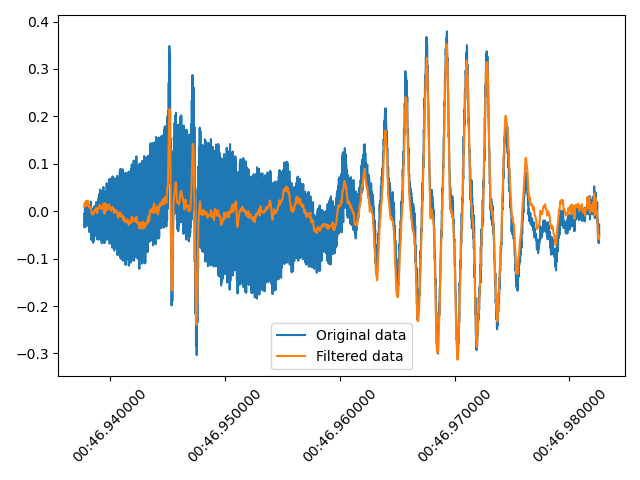

In [6]:
start_time = np.datetime64("2021-07-01T02:00:46.9378", "ns")
stop_time = np.datetime64("2021-07-01T02:00:46.9826", "ns")
filtered_mms1_edp_hmfe_par_epar_brst_l2 = filtered_mms1_edp_hmfe_par_epar_brst_l2[start_time:stop_time]
mms1_edp_hmfe_par_epar_brst_l2 = mms1_edp_hmfe_par_epar_brst_l2[start_time:stop_time]

plt.figure()
plt.plot(mms1_edp_hmfe_par_epar_brst_l2.time, mms1_edp_hmfe_par_epar_brst_l2.values, label="Original data")
plt.plot(filtered_mms1_edp_hmfe_par_epar_brst_l2.time, filtered_mms1_edp_hmfe_par_epar_brst_l2.values, label="Filtered data")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()